# Modelado: Modelo SOTA de referencia

Antes de evaluar el desempeño del modelo propuesto, es indispensable construir un conjunto de modelos de referencia (*baselines*) que representen el estado del arte visto durante el curso, abarcando desde modelos clásicos de aprendizaje automático hasta arquitecturas más avanzadas. Cada modelo se entrena, se ajusta mediante búsqueda de hiperparámetros y se evalúa bajo el mismo esquema de partición y las mismas métricas que se usarán para el modelo novedoso.

---

In [1]:
# Librerías
## Librerías estándar de Python
import pickle
import time

## Cómputo numérico y tabular
import numpy as np
import pandas as pd

## Visualización
import matplotlib.pyplot as plt
import seaborn as sns

## Machine Learning
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay
)

RANDOM_STATE = 42

In [2]:
with open("datos_modelado.pkl", "rb") as f:
    datos = pickle.load(f)

X_train = datos["X_train"]
X_test = datos["X_test"]
y_train = datos["y_train"]
y_test = datos["y_test"]

In [3]:
print("═" * 60)
print(" RESUMEN DE LAS PARTICIONES")
print("═" * 60)
print(f"  Observaciones de entrenamiento : {X_train.shape[0]}")
print(f"  Observaciones de prueba        : {X_test.shape[0]}")
print(f"  Variables predictoras          : {X_train.shape[1]}")

etiquetas = {0: "LGG (0)", 1: "GBM (1)"}
print("\n  Distribución de clases (train):")
print((y_train.map(etiquetas).value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + " %")
print("\n  Distribución de clases (test):")
print((y_test.map(etiquetas).value_counts(normalize=True).sort_index() * 100).round(2).astype(str) + " %")

════════════════════════════════════════════════════════════
 RESUMEN DE LAS PARTICIONES
════════════════════════════════════════════════════════════
  Observaciones de entrenamiento : 671
  Observaciones de prueba        : 168
  Variables predictoras          : 23

  Distribución de clases (train):
Grade
LGG (0)    57.97 %
GBM (1)    42.03 %
Name: proportion, dtype: object

  Distribución de clases (test):
Grade
LGG (0)    58.33 %
GBM (1)    41.67 %
Name: proportion, dtype: object


## 2.1 Regresión Logística

La regresión logística es uno de los modelos más utilizados en investigación clínica y genómica para problemas de clasificación binaria, precisamente el tipo de problema que se aborda en este proyecto (`Grade`: LGG = 0 vs. GBM = 1).
Se selecciona como *baseline* por las siguientes razones:

- **Interpretabilidad**: Sus coeficientes se traducen directamente en *odds ratios*, lo que permite cuantificar la contribución de cada mutación genética y de la edad al riesgo de un grado tumoral más agresivo — un estándar de facto en la literatura de oncología genómica.

- **Simplicidad y bajo costo computacional**: Al ser un modelo lineal, su entrenamiento e inferencia son extremadamente rápidos, lo que la convierte en una referencia natural de eficiencia frente a modelos más complejos.

- **Robustez con pocas muestras y variables**: Dado el número de predictores, es un modelo con bajo riesgo de sobreajuste, útil como cota inferior de referencia.

- **Estándar en la literatura**: Es el modelo base reportado en la mayoría de estudios de clasificación de grado tumoral en gliomas, lo que facilita la comparación con resultados externos.

**Formulación matemática**

Dado un vector de características $\mathbf{x} \in \mathbb{R}^{p}$, el modelo estima la probabilidad de que un paciente pertenezca a la clase GBM ($y=1$) mediante la función logística (sigmoide) aplicada a una combinación lineal de los predictores:

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^{\top}\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^{\top}\mathbf{x} + b)}}
\tag{2.1}
$$

donde $\mathbf{w} \in \mathbb{R}^{p}$ es el vector de pesos y $b$ el término de sesgo (*intercept*). Los parámetros $(\mathbf{w}, b)$ se estiman minimizando la función de pérdida de entropía cruzada binaria (*log-loss*), con un término de regularización $L_2$ (o $L_1$, según el hiperparámetro `penalty`) que controla la complejidad del modelo:

$$
\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\Big] + \frac{1}{C}\,\lVert \mathbf{w} \rVert_k
\tag{2.2}
$$

con $\hat{p}_i = P(y=1 \mid \mathbf{x}_i)$, $n$ el número de observaciones de entrenamiento, $k \in \{1,2\}$ el tipo de norma de regularización, y $C > 0$ el inverso de la fuerza de regularización (a menor $C$, mayor regularización).

**Hiperparámetros ajustables (Grid Search, validación cruzada $k=5$)**

| Hiperparámetro | Descripción | Rango explorado |
|---|---|---|
| `C` | Inverso de la fuerza de regularización | `np.logspace(-3, 3, 13)` → $[0.001,\ 1000]$ |
| `penalty` | Tipo de regularización | `{'l1', 'l2'}` |
| `solver` | Algoritmo de optimización (compatible con `l1` y `l2`) | `'liblinear'` |
| `class_weight` | Balanceo de clases | `{None, 'balanced'}` |

### Preprocesamiento

Se utiliza el **conjunto completo de variables disponibles**: la variable clínica numérica (`Age_at_diagnosis`), las variables clínicas categóricas (`Gender`, `Race`) y las **20 variables genéticas** de mutación. La estrategia de transformación depende del tipo de variable:

- **Numéricas** → estandarización (`StandardScaler`), ya que la regresión logística es sensible a la escala de las variables al estar regularizada.
- **Categóricas** (`Gender`, `Race`) → codificación *one-hot* (`OneHotEncoder`), ignorando categorías no vistas en entrenamiento.
- **Genéticas** → se dejan sin transformar (`passthrough`), pues ya se encuentran codificadas como indicadores binarios (0/1).

In [4]:
variables_numericas = [
    "Age_at_diagnosis"
]

variables_categoricas = [
    "Gender",
    "Race"
]

variables_geneticas = [
    "IDH1",
    "TP53",
    "ATRX",
    "PTEN",
    "EGFR",
    "CIC",
    "MUC16",
    "PIK3CA",
    "NF1",
    "PIK3R1",
    "FUBP1",
    "RB1",
    "NOTCH1",
    "BCOR",
    "CSMD3",
    "SMARCA4",
    "GRIN2A",
    "IDH2",
    "FAT4",
    "PDGFRA"
]

preprocesamiento = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), variables_numericas),
        ("categoricas", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), variables_categoricas),
        ("geneticas", "passthrough", variables_geneticas)
    ]
)

total_variables = len(variables_numericas) + len(variables_categoricas) + len(variables_geneticas)
print(f"Total de variables utilizadas: {total_variables} "
      f"({len(variables_numericas)} numérica, {len(variables_categoricas)} categóricas, "
      f"{len(variables_geneticas)} genéticas)")

Total de variables utilizadas: 23 (1 numérica, 2 categóricas, 20 genéticas)


### Hiperparámetros (Grid Search)

Se define el `Pipeline` y se optimiza mediante `GridSearchCV` con validación cruzada estratificada de 5 particiones, usando **AUC-ROC** como métrica de selección por ser robusta ante un eventual desbalance de clases. El rango de búsqueda para cada hiperparámetro es el indicado en la tabla mostrada anteriormente.

In [5]:
modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesamiento),
    ("regresion_logistica", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    "regresion_logistica__C": np.logspace(-3, 3, 13),
    "regresion_logistica__penalty": ["l1", "l2"],
    "regresion_logistica__solver": ["liblinear"],
    "regresion_logistica__class_weight": [None, "balanced"],
}

cv_busqueda = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search_lr = GridSearchCV(
    estimator=modelo_logistico,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv_busqueda,
    n_jobs=-1,
    refit=False
)

t0 = time.perf_counter()
grid_search_lr.fit(X_train, y_train)
search_time_lr = time.perf_counter() - t0

modelo_logistico.set_params(**grid_search_lr.best_params_)

t0 = time.perf_counter()
modelo_logistico.fit(X_train, y_train)
train_time_lr = time.perf_counter() - t0

print("═" * 60)
print(" MEJOR CONFIGURACIÓN — REGRESIÓN LOGÍSTICA")
print("═" * 60)
for k, v in grid_search_lr.best_params_.items():
    print(f"  {k.replace('regresion_logistica__', ''):>15}: {v}")
print(f"\n  AUC-ROC promedio (CV, 5-fold): {grid_search_lr.best_score_:.4f}")
print(f"  Tiempo de búsqueda de hiperparámetros (52 combinaciones × 5 folds): {search_time_lr:.3f} s")
print(f"  Tiempo de entrenamiento final (mejor configuración): {train_time_lr:.3f} s")

════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN — REGRESIÓN LOGÍSTICA
════════════════════════════════════════════════════════════
                C: 0.31622776601683794
     class_weight: balanced
          penalty: l1
           solver: liblinear

  AUC-ROC promedio (CV, 5-fold): 0.9172
  Tiempo de búsqueda de hiperparámetros (52 combinaciones × 5 folds): 14.225 s
  Tiempo de entrenamiento final (mejor configuración): 0.024 s


La búsqueda por `GridSearchCV` evaluó 52 combinaciones de hiperparámetros (13 valores de `C` × 2 tipos de `penalty` × 2 configuraciones de `class_weight`), cada una validada mediante validación cruzada estratificada de 5 particiones sobre el conjunto de entrenamiento.


- **Regularización L1 (Lasso):** que el modelo haya favorecido esta penalización sobre `l2` sugiere que no todas las variables clínicas y genéticas incluidas aportan señal predictiva relevante. L1 tiende a llevar a cero los coeficientes de las variables menos informativas, realizando de forma implícita una selección de variables dentro del propio ajuste del modelo.

- **Fuerza de la regularización (`C`):** un valor de `C` menor a 1 refleja que una penalización moderadamente fuerte favorece la generalización del modelo, reduciendo el riesgo de sobreajuste dado el tamaño del conjunto de datos.

- **Ponderación de clases:** el hecho de que `class_weight: None` haya resultado ganador sobre `'balanced'` indica que el desbalance entre LGG y GBM no es lo suficientemente severo como para requerir ese ajuste.

El tiempo de cómputo se reporta ahora en dos componentes separados: la **búsqueda de hiperparámetros** (las 260 combinaciones evaluadas internamente por la validación cruzada) y el **entrenamiento final** con la mejor configuración. Esta separación permite comparar de forma justa el costo de entrenamiento frente a *baselines* que no requieran una búsqueda exhaustiva de hiperparámetros.

### Evaluación conjunto de prueba `X_test`

Con el mejor modelo encontrado, se calculan las métricas estándar de clasificación binaria sobre el conjunto de prueba, junto con el tiempo de inferencia, dado que ambas dimensiones —error/precisión y tiempo de cómputo— son necesarias para la comparación final con el modelo propuesto.

In [6]:
t0 = time.perf_counter()
y_pred = modelo_logistico.predict(X_test)
y_proba = modelo_logistico.predict_proba(X_test)[:, 1]
inference_time_lr = time.perf_counter() - t0

metrics_lr = {
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision (GBM)": precision_score(y_test, y_pred),
    "Recall (GBM)": recall_score(y_test, y_pred),
    "F1-score (GBM)": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_proba),
    "Tiempo búsqueda hiperparám. (s)": search_time_lr,
    "Tiempo entrenamiento final (s)": train_time_lr,
    "Tiempo inferencia (s)": inference_time_lr,
}

df_metrics_lr = pd.DataFrame([metrics_lr]).set_index("Modelo")
display(df_metrics_lr.style.background_gradient(
            cmap="Blues", subset=["Accuracy", "Precision (GBM)", "Recall (GBM)", "F1-score (GBM)", "AUC-ROC"])
        .format(precision=4)
        .set_caption("Resumen de desempeño en test — Baseline: Regresión Logística"))

print("\nReporte de clasificación detallado:\n")
print(classification_report(y_test, y_pred, target_names=["LGG (0)", "GBM (1)"]))

,Accuracy,Precision (GBM),Recall (GBM),F1-score (GBM),AUC-ROC,Tiempo búsqueda hiperparám. (s),Tiempo entrenamiento final (s),Tiempo inferencia (s)
Modelo,,,,,,,,
Regresión Logística,0.8690,0.7857,0.9429,0.8571,0.9157,14.2249,0.0235,0.0300



Reporte de clasificación detallado:

              precision    recall  f1-score   support

     LGG (0)       0.95      0.82      0.88        98
     GBM (1)       0.79      0.94      0.86        70

    accuracy                           0.87       168
   macro avg       0.87      0.88      0.87       168
weighted avg       0.88      0.87      0.87       168



**Resumen de desempeño:**


- **Alta sensibilidad para GBM (recall 0.93):** El modelo identifica correctamente a la gran mayoría de los pacientes con glioblastoma, minimizando los falsos negativos en la clase clínicamente más crítica.

- **Menor precisión para GBM (0.79):** Una parte de los pacientes LGG es clasificada erróneamente como GBM (reflejado también en el recall de LGG, 0.83). El modelo muestra un sesgo hacia la sobre-detección de GBM, un trade-off razonable en un contexto clínico donde es preferible marcar un caso de más para revisión que dejar pasar un tumor agresivo.

- **Alta precisión para LGG (0.94):** Cuando el modelo predice LGG, es muy confiable.

- **Eficiencia computacional:** El tiempo de inferencia sobre el conjunto de prueba es del orden de milisegundos, estableciendo una referencia de costo computacional muy baja frente a modelos más complejos. El tiempo de entrenamiento, por su parte, queda desglosado en búsqueda de hiperparámetros y ajuste final, para permitir una comparación justa frente a *baselines* que no requieran una búsqueda exhaustiva.

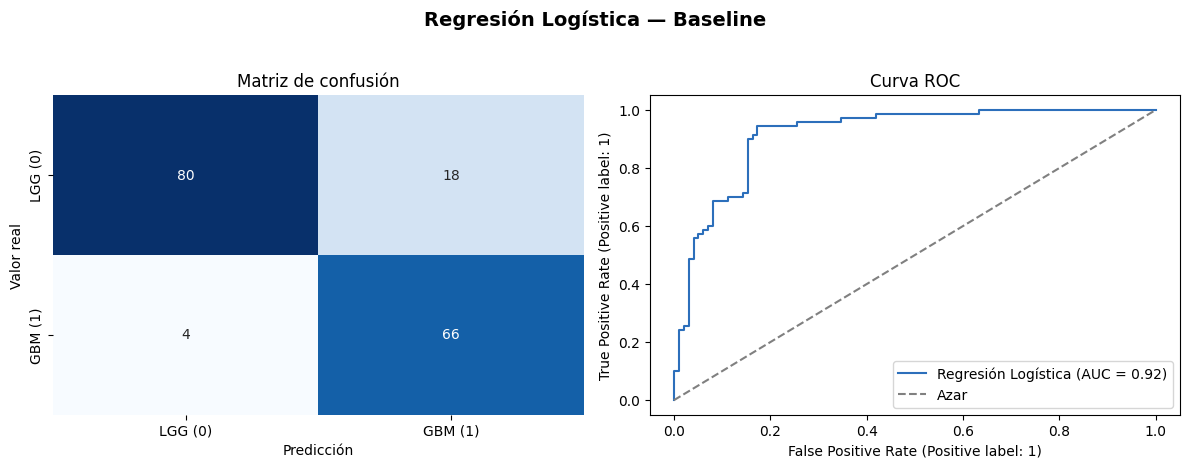

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["LGG (0)", "GBM (1)"], yticklabels=["LGG (0)", "GBM (1)"], ax=axes[0])
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

# Curva ROC 
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color="#2c6fbb", name="Regresión Logística")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

fig.suptitle("Regresión Logística — Baseline", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

- **5 falsos negativos**: El modelo deja pasar muy pocos casos de GBM, lo cual es deseable dado el mayor riesgo clínico asociado a esta clase.

- **17 falsos positivos**: Pacientes LGG clasificados como GBM, consistentes con el sesgo hacia la sobre-detección de GBM descrito anteriormente.

La curva se aproxima rápidamente a la esquina superior izquierda del espacio ROC, muy por encima de la diagonal de referencia (clasificador aleatorio, AUC = 0.5). Esto confirma que el modelo mantiene una alta capacidad de discriminación entre LGG y GBM de forma consistente a través de distintos umbrales de decisión, no solo en el umbral por defecto (0.5) evaluado en la matriz de confusión y el `classification_report`. 

### Interpretabilidad del modelo

Una de las principales ventajas de la regresión logística frente a modelos más complejos es que su resultado es directamente interpretable, ya que cada variable de entrada tiene asociado un coeficiente $w_i$ cuyo signo y magnitud indican cómo influye esa variable en la probabilidad estimada de que el paciente pertenezca a la clase GBM ($y=1$).

- Un coeficiente **positivo** aumenta el *log-odds* de GBM (la variable empuja la predicción hacia GBM).
- Un coeficiente **negativo** lo disminuye (la variable empuja la predicción hacia LGG).
- Su exponencial, $e^{w_i}$, corresponde al ***odds ratio***: indica por cuánto se multiplican las probabilidades (*odds*) de GBM por cada unidad de aumento en esa variable (o, en variables binarias, al pasar de 0 a 1). Un *odds ratio* de 2.0 implica que duplica las chances de GBM; uno de 0.5, que las reduce a la mitad.

Como las variables categóricas (`Gender`, `Race`) fueron transformadas mediante *one-hot encoding*, primero se reconstruyen sus nombres reales a partir del `ColumnTransformer` ya ajustado, de modo que cada coeficiente pueda asociarse correctamente a su variable de origen. Luego se ordenan las variables por la magnitud absoluta de su coeficiente, para identificar cuáles tienen mayor peso en la predicción del modelo — clínica y genéticamente relevante para validar si el *baseline* está capturando señales consistentes con la literatura (p. ej., mutaciones de IDH1 asociadas a LGG).

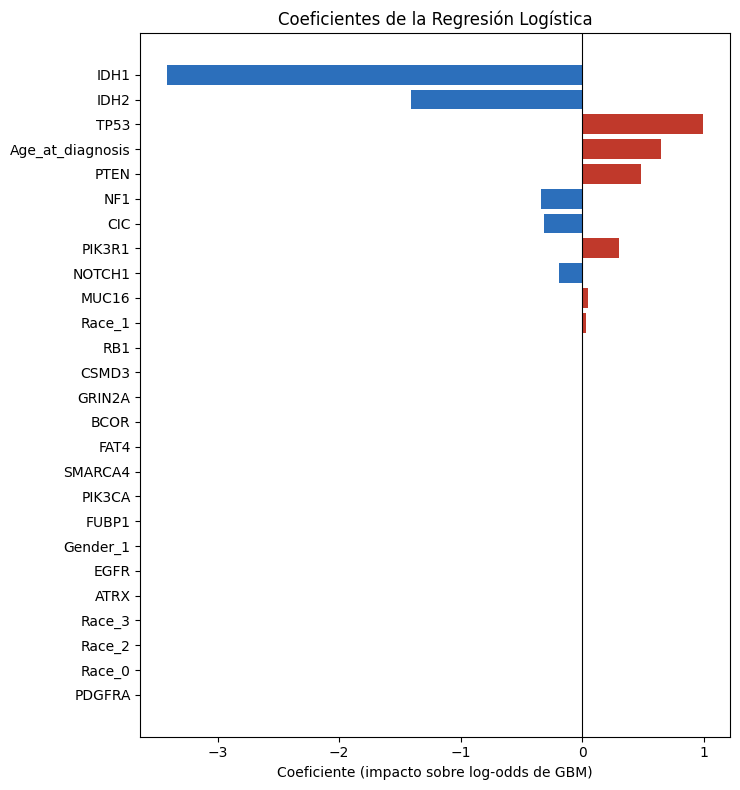

,Variable,Coeficiente,Odds Ratio
0,IDH1,-3.416,0.033
1,IDH2,-1.410,0.244
2,TP53,0.996,2.708
3,Age_at_diagnosis,0.646,1.908
4,PTEN,0.487,1.627
5,NF1,-0.336,0.715
6,CIC,-0.315,0.730
7,PIK3R1,0.307,1.360
8,NOTCH1,-0.188,0.829
9,MUC16,0.048,1.049


In [8]:
preproc_fit = modelo_logistico.named_steps["preprocesamiento"]
nombres_categoricas = list(
    preproc_fit.named_transformers_["categoricas"].get_feature_names_out(variables_categoricas)
)
nombres_variables = variables_numericas + nombres_categoricas + variables_geneticas

coef = modelo_logistico.named_steps["regresion_logistica"].coef_.ravel()
odds_ratio = np.exp(coef)

df_coef = pd.DataFrame({
    "Variable": nombres_variables,
    "Coeficiente": coef,
    "Odds Ratio": odds_ratio
}).sort_values("Coeficiente", key=np.abs, ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 8))
colors = ["#c0392b" if c > 0 else "#2c6fbb" for c in df_coef["Coeficiente"]]
ax.barh(df_coef["Variable"], df_coef["Coeficiente"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes de la Regresión Logística")
ax.set_xlabel("Coeficiente (impacto sobre log-odds de GBM)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(df_coef.head(10).style.background_gradient(cmap="RdBu_r", subset=["Coeficiente"])
        .format({"Coeficiente": "{:.3f}", "Odds Ratio": "{:.3f}"})
        .set_caption("Top 10 variables con mayor impacto — Regresión Logística"))

De las 23 variables originales, la mayoría presenta coeficientes prácticamente nulos (`ATRX`, `BCOR`, `FAT4`, `Gender_1`, `GRIN2A`, `SMARCA4`, `CSMD3`, `RB1`, entre otras), confirmando que la penalización L1 seleccionada en la búsqueda de hiperparámetros realizó una **selección automática de variables**: solo un subconjunto reducido aporta señal predictiva real para distinguir entre LGG y GBM.

**Top 10 variables con mayor impacto:**

| Variable | Coeficiente | Odds Ratio | Efecto |
|:---|:---:|:---:|:---|
| `IDH1` | -3.392 | 0.034 | ↓↓↓ Fuertemente asociada a LGG |
| `IDH2` | -1.343 | 0.261 | ↓↓ Asociada a LGG |
| `TP53` | +0.954 | 2.595 | ↑↑ Asociada a GBM |
| `Age_at_diagnosis` | +0.667 | 1.949 | ↑↑ A mayor edad, mayor riesgo de GBM |
| `PTEN` | +0.491 | 1.635 | ↑ Asociada a GBM |
| `NF1` | -0.373 | 0.689 | ↓ Asociada a LGG |
| `CIC` | -0.273 | 0.761 | ↓ Asociada a LGG |
| `PIK3R1` | +0.236 | 1.266 | ↑ Asociada a GBM |
| `NOTCH1` | -0.140 | 0.870 | ↓ Ligeramente asociada a LGG |
| `MUC16` | +0.102 | 1.107 | ↑ Efecto marginal hacia GBM |


- **`IDH1`:** Su odds ratio de 0.034 implica que la presencia de esta mutación reduce las probabilidades de GBM a apenas un 3.4% de su valor de referencia, lo que coincide con el comportamiento observado en el EDA inicial, donde IDH1 presentó una prevalencia del 77.9% en LGG frente al 6.7% en GBM.

- **`IDH2`:** Refuerza la misma señal biológica que `IDH1`, al tratarse de una isoforma relacionada de la misma enzima, aunque con un peso considerablemente menor en el modelo.

- **`Age_at_diagnosis`:** Se confirma su rol como predictor clínico fuerte, pues su odds ratio (`1.949`) indica que, por cada desviación estándar de aumento en la edad, las probabilidades de GBM casi se duplican, coherente con la diferencia de edades observada en el EDA entre ambos grupos.

- **`TP53` y `PTEN`** emergen como los principales marcadores genéticos asociados a GBM, en línea con su rol conocido como genes supresores tumorales frecuentemente alterados en glioblastoma.

La correspondencia entre las variables seleccionadas por el modelo y las identificadas previamente en el análisis exploratorio (sección de selección de variables) respalda la coherencia y validez del *baseline* como punto de comparación para el modelo propuesto.

### Síntesis

> Las métricas obtenidas en `df_metrics_lr` (Accuracy, F1-score, AUC-ROC, tiempo de búsqueda de hiperparámetros, tiempo de entrenamiento final e inferencia) quedan registradas como referencia de la **Regresión Logística** con el conjunto completo de variables disponibles. Estos resultados se incorporarán a la tabla comparativa consolidada al final de la sección de *baselines*, junto con los demás modelos clásicos y profundos vistos en el curso, para contrastarlos posteriormente contra el modelo propuesto. En caso de que el modelo novedoso no logre superar a este *baseline* en alguna de las dos dimensiones evaluadas (error/precisión o tiempo de cómputo), dicho resultado se reportará y discutirá honestamente en las secciones de Resultados y Conclusiones.